In [1]:
import torch
import torchvision
import torchvision.transforms as T
import os
import numpy as np
import cv2
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_Weights

In [2]:
os.getcwd()

'/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION'

In [3]:
os.chdir("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection")
os.getcwd()
from Solar_Rooftop_Detection.get_bounding_box_cordinates import bounding_box

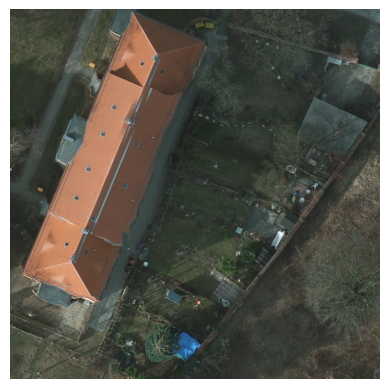

In [4]:
demo_img = cv2.imread("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/TREE_DATASET/train/images/top_potsdam_2_10_RGB_0_1024.png")
demo_img = cv2.cvtColor(demo_img, cv2.COLOR_BGR2RGB)
import matplotlib.pyplot as plt
plt.imshow(demo_img)
plt.axis('off')
plt.show()

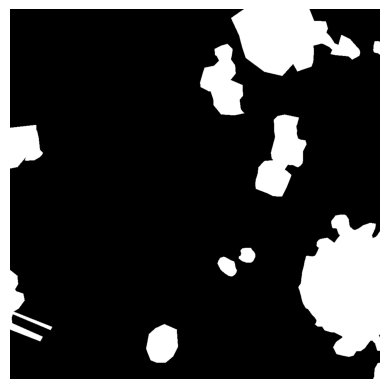

In [5]:
demo_mask = cv2.imread("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/TREE_DATASET/train/masks/top_potsdam_2_10_RGB_0_1024.png",cv2.IMREAD_GRAYSCALE)
plt.imshow(demo_mask, cmap='gray')
plt.axis('off')
plt.show()

In [6]:
import cv2
import numpy as np

def extract_individual_objects(input_mask):
    # Ensure the input is a binary mask (0 and 255 values)
    _, binary_mask = cv2.threshold(input_mask, 127, 255, cv2.THRESH_BINARY)

    # Find contours (connected components) in the binary mask
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # List to hold individual object masks
    object_masks = []
    bounding_boxes = []

    # Iterate over each contour to create an individual mask
    for contour in contours:
        # Create a blank mask with the same size as the original mask
        object_mask = np.zeros_like(binary_mask)
        
        x, y, w, h = cv2.boundingRect(contour)
        bounding_boxes.append((x, y, x+w, y+h))
        
        # Draw the current contour on the object mask (white)
        cv2.drawContours(object_mask, [contour], -1, (255), thickness=cv2.FILLED)

        # Append the object mask to the list
        object_masks.append(object_mask)

    return object_masks, bounding_boxes

In [7]:
demo_mask.shape

(1024, 1024)

In [8]:
multiple_masks, bb = extract_individual_objects(demo_mask)
len(multiple_masks), len(bb)

(11, 11)

In [9]:
M = np.array(multiple_masks)
M

array([[[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
        [  0,   0,   0, ..., 255, 255, 255],
        [  0,   0,   0, ..., 255, 255, 255],
        [  0,   0,   0, ..., 255, 255, 255]],

       [[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0]],

       [[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0]],

       ...,

       [[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0

In [10]:
M.shape

(11, 1024, 1024)

In [11]:
multiple_masks[0].shape

(1024, 1024)

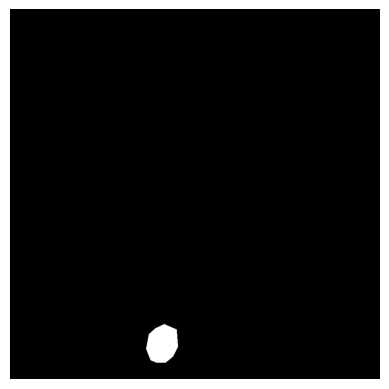

In [12]:
plt.imshow(multiple_masks[1], cmap='gray')
plt.axis('off')
plt.show()

In [ ]:

# Define the dataset
class RooftopDataset(Dataset):
    def __init__(self, root, transforms=None):
        self.root = root
        self.transforms = transforms
        self.images_dir = os.path.join(root, 'images')
        self.masks_dir = os.path.join(root, 'masks')
        self.imgs = sorted([f for f in os.listdir(self.images_dir)])
        self.masks = sorted([f for f in os.listdir(self.masks_dir)])

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_dir, self.imgs[idx])
        mask_path = os.path.join(self.masks_dir, self.masks[idx])

        # Load image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = T.ToTensor()(img)

        # Load multi-instance mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        # # Extract unique objects (assuming different objects have different pixel values)
        # obj_ids = np.unique(mask)[1:]  # Ignore background (0)
        # masks = (mask == obj_ids[:, None, None]).astype(np.uint8)  # Convert to binary masks

        # # Compute bounding boxes for each object
        # boxes = bounding_box(mask)
        
        # mask = np.where(mask > 0, 1, 0).astype(np.uint8)
        
        # mask = torch.as_tensor(mask, dtype=torch.uint8).unsqueeze(0) # Add channel dimension
        
        masks, boxes = extract_individual_objects(mask)
        
        if not masks or not boxes:
            print(f"Mask failed to load for image {img_path}")
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            masks = torch.zeros((0, 1024, 1024), dtype=torch.uint8)
            labels = torch.zeros((0,), dtype=torch.int64)
        else :            
            masks = np.stack(masks, axis=0)
            masks = torch.from_numpy(masks).to(dtype=torch.uint8)
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.ones((len(boxes),), dtype=torch.int64)  # Assume all belong to class 1
            
        # print(len(masks), len(boxes))

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks,
            "image_id": torch.tensor([idx])
        }
        if self.transforms is not None:
            img, target = self.transforms(img, target)


        return img, target

    def __len__(self):
        return len(self.imgs)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    
root_dir = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_images_1024_1024/" 

dataset = RooftopDataset(root_dir)
data_loader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
# data_loader


# Load a pre-trained Mask R-CNN model and modify for fine-tuning
def get_model_instance_segmentation(num_classes = 1):
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1)

    # Modify the bounding box predictor
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # Modify the mask predictor
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256  # Default in Mask R-CNN
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)

    return model


num_classes = 2
my_model = get_model_instance_segmentation(num_classes = num_classes)

optimizer = torch.optim.Adam(my_model.parameters(), lr=0.0001)


def train_model(model, data_loader, optimizer, device, num_epochs=10):
    
    print("Training the model...") 
    model.to(device)    
    model.train()

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        total_loss = 0
        
        for images, targets in data_loader:
            print("images and targets are loaded", )
            
            images = [img.to(device) for img in images]
            
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            loss_dict = model(images, targets)
            
            losses = sum(loss for loss in loss_dict.values())

            optimizer.zero_grad()
            losses.backward()
            optimizer.step()

            total_loss += losses.item()

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss:.4f}")



train_model(my_model, data_loader, optimizer, device, num_epochs=10)

Training the model...
Epoch 1/10
10 10
295 295
33 33
117 117
images and targets are loaded
10 10
370 370
86 86
409 409
images and targets are loaded
15 15
14 14
84 84
215 215
images and targets are loaded
53 53
14 14
46 46
86 86
images and targets are loaded
24 24
4 4
53 53
14 14
images and targets are loaded
31 31
45 45
17 17
51 51
images and targets are loaded
17 17
20 20
80 80
3 3
images and targets are loaded
2 2
1 1
13 13
30 30
images and targets are loaded
90 90
48 48
78 78
21 21
images and targets are loaded
63 63
11 11
47 47
14 14
images and targets are loaded
Mask failed to load for image /home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_images_1024_1024/images/2190.jpg
0 0
32 32
39 39
90 90
images and targets are loaded
138 138
17 17
9 9
13 13
images and targets are loaded
59 59
169 169
22 22
21 21
images and targets are loaded
Mask failed to load for image /home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_images_1024_1024/images/1368.jpg
0 0
22 22
42 42
205 205
images and target

In [ ]:
num_classes = 2

In [4]:
os.chdir("../")
os.getcwd()

'/home/selc-a4-sr2/Solar_Rooftop_Detection'

In [5]:
os.listdir(os.getcwd())

['requirements.txt',
 'Arial_test_images',
 'output_images',
 '.git',
 'Arial_validation_images',
 'sam_vit_b.pth',
 'ReadMe.MD',
 'checkpoints',
 '.gitignore',
 'Solar_Rooftop_Detection',
 'BaseLineModels',
 'Arial_images_1024_1024',
 'demo.py',
 'Solar_rooftop_Detection_indian_images',
 'test.ipynb',
 'logs']

In [16]:
# Load a pre-trained Mask R-CNN model and modify for fine-tuning
def get_model_instance_segmentation(num_classes = 1):
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True)

    # Modify the bounding box predictor
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # Modify the mask predictor
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256  # Default in Mask R-CNN
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)

    return model

In [17]:
my_model = get_model_instance_segmentation()
my_model

/home/selc-a4-sr2/myenv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/selc-a4-sr2/myenv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [19]:
optimizer = torch.optim.Adam(my_model.parameters(), lr=0.0001)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
optimizer = torch.optim.Adam(my_model.parameters(), lr=0.0001)

def train_model(model, data_loader, optimizer, device, num_epochs=10):
    
    print("Training the model...") 
    model.to(device)
    model.train()

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        total_loss = 0
        for images, targets in data_loader:
            print("images and targets are loaded", )
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            optimizer.zero_grad()
            losses.backward()
            optimizer.step()

            total_loss += losses.item()

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss:.4f}")


In [33]:
for i in data_loader:
    one , exp = i
    break

In [35]:
len(one)

4

In [36]:
len(exp)

4

In [37]:
exp

({'boxes': tensor([]),
  'labels': tensor([1]),
  'masks': tensor([[[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           ...,
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]]], dtype=torch.uint8),
  'image_id': tensor([1148])},
 {'boxes': tensor([]),
  'labels': tensor([1]),
  'masks': tensor([[[0, 0, 0,  ..., 1, 1, 1],
           [0, 0, 0,  ..., 1, 1, 1],
           [0, 0, 0,  ..., 1, 1, 1],
           ...,
           [1, 1, 1,  ..., 0, 0, 0],
           [1, 1, 1,  ..., 0, 0, 0],
           [1, 1, 1,  ..., 0, 0, 0]]], dtype=torch.uint8),
  'image_id': tensor([32])},
 {'boxes': tensor([]),
  'labels': tensor([1]),
  'masks': tensor([[[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           ...,
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]]], dtype=tor

In [31]:
train_model(my_model, data_loader, optimizer, device, num_epochs=10)


Training the model...
Epoch 1/10
images and targets are loaded


AssertionError: Expected target boxes to be a tensor of shape [N, 4], got torch.Size([0]).

# Final Code 

In [13]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

In [14]:
print(os.getcwd())

/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection


In [15]:
# Your function to extract individual masks and bounding boxes
def extract_individual_objects(input_mask):
    # Ensure the input is a binary mask (0 and 255 values)
    _, binary_mask = cv2.threshold(input_mask, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    object_masks = []
    bounding_boxes = []
    for contour in contours:
        object_mask = np.zeros_like(binary_mask)
        x, y, w, h = cv2.boundingRect(contour)
        bounding_boxes.append([x, y, x + w, y + h])  # [x_min, y_min, x_max, y_max]
        cv2.drawContours(object_mask, [contour], -1, 255, thickness=cv2.FILLED)
        object_masks.append(object_mask // 255)  # Convert to 0/1 binary
    return object_masks, bounding_boxes


In [16]:
# Define the dataset
class RooftopDataset(Dataset):
    def __init__(self, root, transforms=None):
        self.root = root
        self.transforms = transforms
        self.images_dir = os.path.join(root, 'images')
        self.masks_dir = os.path.join(root, 'masks')
        self.imgs = sorted([f for f in os.listdir(self.images_dir) if f.endswith(('.jpg', '.png'))])
        self.masks = sorted([f for f in os.listdir(self.masks_dir) if f.endswith(('.jpg', '.png'))])
        assert len(self.imgs) == len(self.masks), "Mismatch between images and masks"

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_dir, self.imgs[idx])
        mask_path = os.path.join(self.masks_dir, self.masks[idx])

        # Load image
        img = cv2.imread(img_path)
        if img is None:
            raise FileNotFoundError(f"Failed to load image: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = T.ToTensor()(img)  # Shape: (3, 1024, 1024)

        # Load multi-instance mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            # print(f"Warning: Mask failed to load for {mask_path}")
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            masks = torch.zeros((0, 1024, 1024), dtype=torch.uint8)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            # Extract individual masks and boxes
            instance_masks, boxes = extract_individual_objects(mask)
            if not instance_masks or not boxes:
                # print(f"No rooftops detected in {img_path}")
                boxes = torch.zeros((0, 4), dtype=torch.float32)
                masks = torch.zeros((0, 1024, 1024), dtype=torch.uint8)
                labels = torch.zeros((0,), dtype=torch.int64)
            else:
                # Validate consistency
                assert len(boxes) == len(instance_masks), f"Mismatch: {len(boxes)} boxes vs {len(instance_masks)} masks"
                
                # Stack masks and convert to tensor
                masks = np.stack(instance_masks, axis=0)  # Shape: (num_instances, 1024, 1024)
                masks = torch.from_numpy(masks).to(dtype=torch.uint8)
                
                # Convert boxes to tensor
                boxes = torch.as_tensor(boxes, dtype=torch.float32)  # Shape: (num_instances, 4)
                
                # Assign labels (all 1 for rooftops)
                labels = torch.ones((len(instance_masks),), dtype=torch.int64)
                
                # Debug info
                # print(f"{img_path}: {len(instance_masks)} rooftops")

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks,
            "image_id": torch.tensor([idx])
        }

        if self.transforms:
            img, target = self.transforms(img, target)

        return img, target

    def __len__(self):
        return len(self.imgs)

In [17]:
# Load and modify the model
def get_model_instance_segmentation(num_classes=2):  # Background (0) + Rooftop (1)
    model = maskrcnn_resnet50_fpn(weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)
    return model

In [18]:
# Training function with enhanced logging
def train_model(model, data_loader, optimizer, device, num_epochs=10):
    # print("Training the model...")
    model.to(device)
    model.train()
    losses_list = []

    for epoch in range(num_epochs):
        # print(f"Epoch {epoch+1}/{num_epochs}")
        total_loss = 0
        for i, (images, targets) in enumerate(data_loader):
            # print(f"Batch {i+1}: Images and targets loaded")
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            
            # Log individual losses
            # print(f"Batch {i+1} losses: { {k: v.item() for k, v in loss_dict.items()} }")
            
            optimizer.zero_grad()
            losses.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Stabilize training
            optimizer.step()

            total_loss += losses.item()
        
        total_loss = total_loss / len(data_loader)
        print(total_loss)
        losses_list.append(total_loss)
        
        print(f"Epoch [{epoch+1}/{num_epochs}], Total Loss: {total_loss:.4f}")

    return losses_list

In [19]:
root_dir = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/TREE_DATASET/train"
dataset = RooftopDataset(root_dir)
data_loader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=2, collate_fn=lambda x: tuple(zip(*x)))

print("Data is loaded")

device = torch.device("cuda")
num_epochs = 50
num_classes = 2
learning_rate = 0.0001

print("parameter are set")

model = get_model_instance_segmentation(num_classes=num_classes)
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

loss = train_model(model, data_loader, optimizer, device, num_epochs=num_epochs)

save_dir = '/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/results/maskrcnn'

os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, f'mask_rcnn_epoch_{num_epochs}_.pth')
torch.save({'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict()}, save_path)

save_dir = '/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/results/maskrcnn'

os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, f'mask_rcnn_epoch_{num_epochs}_full.pth')
torch.save(model, save_path)

print(f"Model saved at {save_path}")

Data is loaded
parameter are set
1.4580682823044098
Epoch [1/50], Total Loss: 1.4581
1.2154620643147451
Epoch [2/50], Total Loss: 1.2155
1.0737257032337304
Epoch [3/50], Total Loss: 1.0737
0.9616037123574468
Epoch [4/50], Total Loss: 0.9616
0.8725408263906034
Epoch [5/50], Total Loss: 0.8725
0.7715078447750229
Epoch [6/50], Total Loss: 0.7715
0.7078193718801715
Epoch [7/50], Total Loss: 0.7078
0.6425336024244344
Epoch [8/50], Total Loss: 0.6425
0.5992696592193878
Epoch [9/50], Total Loss: 0.5993
0.5607687597146291
Epoch [10/50], Total Loss: 0.5608
0.5250871019092148
Epoch [11/50], Total Loss: 0.5251
0.5047069905760759
Epoch [12/50], Total Loss: 0.5047
0.4763097140246523
Epoch [13/50], Total Loss: 0.4763
0.45170789162912767
Epoch [14/50], Total Loss: 0.4517
0.4364772799486172
Epoch [15/50], Total Loss: 0.4365
0.4144930493331955
Epoch [16/50], Total Loss: 0.4145
0.40568875061894605
Epoch [17/50], Total Loss: 0.4057
0.3950854260585979
Epoch [18/50], Total Loss: 0.3951
0.36802990422277393


In [20]:
loss

[1.4580682823044098,
 1.2154620643147451,
 1.0737257032337304,
 0.9616037123574468,
 0.8725408263906034,
 0.7715078447750229,
 0.7078193718801715,
 0.6425336024244344,
 0.5992696592193878,
 0.5607687597146291,
 0.5250871019092148,
 0.5047069905760759,
 0.4763097140246523,
 0.45170789162912767,
 0.4364772799486172,
 0.4144930493331955,
 0.40568875061894605,
 0.3950854260585979,
 0.36802990422277393,
 0.3726207586284169,
 0.3486631180711849,
 0.3386662715744829,
 0.32892716733995314,
 0.316561551597304,
 0.3127033349996555,
 0.30774118657597527,
 0.2992453412738389,
 0.2897345303037778,
 0.28593810812798803,
 0.2867905982061774,
 0.27287624777792424,
 0.27791930396042897,
 0.26923029847487717,
 0.26029368440905015,
 0.25314655337861913,
 0.25243809681764173,
 0.2458406064246675,
 0.24794729152125514,
 0.23579130228051168,
 0.23786674658516924,
 0.24005245671657746,
 0.2319016105935959,
 0.2341890082566324,
 0.22935271031128432,
 0.22562021650597006,
 0.21937658602070664,
 0.2166474325482

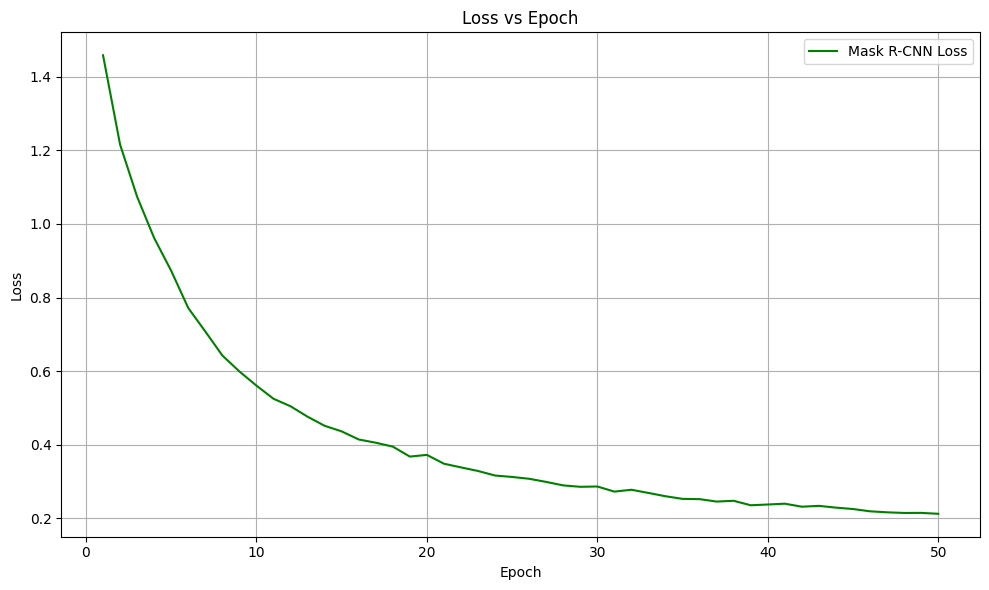

In [21]:
import matplotlib.pyplot as plt
epochs = list(range(1, 51))  
maskrcnn_loss = loss
# Plot Loss
plt.figure(figsize=(10, 6))
plt.plot(epochs, maskrcnn_loss, label='Mask R-CNN Loss', color='green')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.grid(True)
plt.savefig("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/results/maskrcnn/Epoch_vs_Loss_maskRCNN.png")
plt.tight_layout()
plt.show()


# Test Model 

In [32]:
# Load the fine-tuned model
def load_finetuned_model(model_path):
    my_model = torch.load(model_path, weights_only=False)
    my_model.to(device)
    my_model.eval()
    return my_model

In [25]:
os.chdir("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection")
os.getcwd()

'/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection'

In [26]:
from Solar_Rooftop_Detection.accuracy import compute_metrics

In [27]:
def calculate_iou(box1, box2):
    x1, y1, x2, y2 = box1
    x1_p, y1_p, x2_p, y2_p = box2

    xi1, yi1 = max(x1, x1_p), max(y1, y1_p)
    xi2, yi2 = min(x2, x2_p), min(y2, y2_p)
    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)

    box1_area = (x2 - x1) * (y2 - y1)
    box2_area = (x2_p - x1_p) * (y2_p - y1_p)
    union_area = box1_area + box2_area - inter_area

    return inter_area / union_area if union_area > 0 else 0

In [28]:
# Custom IoU calculation for masks
def calculate_mask_iou(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union > 0 else 0

In [29]:
import os
import torch
import numpy as np
import pandas as pd
def evaluate_model(model, data_loader, device, output_dir="test_outputs", iou_threshold=0.5, conf_threshold=0.5):
    """Evaluate a Mask R-CNN model on test data, computing precision, recall, and F1-score for boxes and masks."""
    
    os.makedirs(output_dir, exist_ok=True)
    
    all_tp_boxes, all_fp_boxes, all_fn_boxes = 0, 0, 0
    all_tp_masks, all_fp_masks, all_fn_masks = 0, 0, 0
    all_metrics = []
    
    model.eval()  # Set model to evaluation mode
    
    with torch.no_grad():   
        
        for batch_idx, (images, targets) in enumerate(data_loader):
        
            # print(f"\nProcessing batch {batch_idx + 1}/{len(data_loader)}...")
            # print(f"Number of images in batch: {len(images)}")
            images = [img.to(device) for img in images]
            # print(f"Image shape (first in batch): {images[0].shape}")

            # Model inference
            outputs = model(images)  # List of dicts, one per image
            # print(f"Outputs length: {len(outputs)}, Keys: {outputs[0].keys()}")
            # print(f"Output masks shape: {outputs[0]['masks'].shape}")
            # print(f"Output boxes shape: {outputs[0]['boxes'].shape}")

            # print(f"Targets length: {len(targets)}, Keys: {targets[0].keys()}")
            # print(f"Target masks shape: {targets[0]['masks'].shape}")
            # print(f"Target boxes shape: {targets[0]['boxes'].shape}")
            # loss = model(images, targets)
            # print(f"Loss: {loss}")
            # break
            # Process each image in the batch
            
            for output, target in zip(outputs, targets):
            
                # Ground truth
                gt_boxes = target["boxes"].cpu().numpy()  # [N_gt, 4]
                gt_masks = target["masks"].cpu().numpy()  # [N_gt, H, W]
                gt_labels = target["labels"].cpu().numpy()  # [N_gt]

                # Predictions
                pred_boxes = output["boxes"].cpu().numpy()  # [N_pred, 4]
                pred_scores = output["scores"].cpu().numpy()  # [N_pred]
                pred_masks = output["masks"].cpu().numpy().squeeze(1)  # [N_pred, 1, H, W] -> [N_pred, H, W]
                pred_labels = output["labels"].cpu().numpy()  # [N_pred]

                # Filter predictions by confidence threshold
                mask = pred_scores >= conf_threshold
                pred_boxes = pred_boxes[mask]
                pred_scores = pred_scores[mask]
                pred_masks = pred_masks[mask]
                pred_labels = pred_labels[mask]

                # Evaluate bounding boxes
                matched_gt = set()
                tp_boxes, fp_boxes = 0, 0
                for pred_box in pred_boxes:
                    best_iou = 0
                    best_gt_idx = -1
                    for i, gt_box in enumerate(gt_boxes):
                        if i in matched_gt:
                            continue
                        iou = calculate_iou(pred_box, gt_box)
                        if iou > best_iou:
                            best_iou = iou
                            best_gt_idx = i
                    if best_iou >= iou_threshold:
                        tp_boxes += 1
                        matched_gt.add(best_gt_idx)
                    else:
                        fp_boxes += 1
                fn_boxes = len(gt_boxes) - len(matched_gt)
                all_tp_boxes += tp_boxes
                all_fp_boxes += fp_boxes
                all_fn_boxes += fn_boxes

                # Evaluate masks and compute metrics
                matched_gt_masks = set()
                tp_masks, fp_masks = 0, 0
                M = []
                for pred_idx, pred_mask in enumerate(pred_masks):
                    best_iou = 0
                    best_gt_idx = -1
                    for gt_idx, gt_mask in enumerate(gt_masks):
                        if gt_idx in matched_gt_masks:
                            continue
                        iou = calculate_mask_iou(pred_mask, gt_mask)
                        if iou > best_iou:
                            best_iou = iou
                            best_gt_idx = gt_idx
                    if best_iou >= iou_threshold:
                        tp_masks += 1
                        matched_gt_masks.add(best_gt_idx)
                        # Compute metrics for this true positive pair
                        
                        pred_mask_tensor = torch.from_numpy((pred_mask > 0.5).astype(np.uint8))
                        gt_mask_tensor = torch.from_numpy(gt_mask.astype(np.uint8))
                        metrics = compute_metrics(pred_mask_tensor, gt_mask_tensor)
                        M.append(metrics)
                    else:
                        fp_masks += 1
                        
                fn_masks = len(gt_masks) - len(matched_gt_masks)
                all_tp_masks += tp_masks
                all_fp_masks += fp_masks
                all_fn_masks += fn_masks

                M_mean = np.mean(M, axis=0) if M else [0] * 10
                # print(M_mean)
                all_metrics.append(M_mean)

    
    matrix_df = pd.DataFrame(all_metrics, columns=["pixel_iou", "pixel_dice", "pixel_accuracy", "pixel_precision", "pixel_recall",
                                                   "region_iou", "region_dice", "region_precision", "region_recall", "region_success_accuracy"])     
    matrix_df.to_csv(os.path.join(output_dir, "per_image_mean_metrics.csv"), index=False) 
    
    # Compute average metrics for true positive mask pairs
    if all_metrics:
        avg_metrics = np.mean(all_metrics, axis=0).tolist()
    else:
        avg_metrics = [0.0] * 10
        
        
    # Compute detection metrics for boxes
    precision_boxes = all_tp_boxes / (all_tp_boxes + all_fp_boxes) if (all_tp_boxes + all_fp_boxes) > 0 else 0
    recall_boxes = all_tp_boxes / (all_tp_boxes + all_fn_boxes) if (all_tp_boxes + all_fn_boxes) > 0 else 0
    f1_boxes = 2 * (precision_boxes * recall_boxes) / (precision_boxes + recall_boxes) if (precision_boxes + recall_boxes) > 0 else 0

    # Compute detection metrics for masks
    precision_masks = all_tp_masks / (all_tp_masks + all_fp_masks) if (all_tp_masks + all_fp_masks) > 0 else 0
    recall_masks = all_tp_masks / (all_tp_masks + all_fn_masks) if (all_tp_masks + all_fn_masks) > 0 else 0
    f1_masks = 2 * (precision_masks * recall_masks) / (precision_masks + recall_masks) if (precision_masks + recall_masks) > 0 else 0
    
    # Define column names for CSV
    metric_names = [
        'avg_pixel_iou', 'avg_pixel_dice', 'avg_pixel_accuracy', 'avg_pixel_precision', 'avg_pixel_recall',
        'avg_region_iou', 'avg_region_dice', 'avg_region_precision', 'avg_region_recall', 'avg_region_success_accuracy',
        'box_detection_precision', 'box_detection_recall', 'box_detection_f1',
        'mask_detection_precision', 'mask_detection_recall', 'mask_detection_f1'
    ]

    # Combine all metrics into a single list
    metric_values = avg_metrics + [precision_boxes, recall_boxes, f1_boxes, precision_masks, recall_masks, f1_masks]

    # Create DataFrame and save to CSV
    df = pd.DataFrame([metric_values], columns=metric_names)
    csv_path = os.path.join(output_dir, 'per_images_mean_evaluation_metrics.csv')
    df.to_csv(csv_path, index=False)

    print(f"Evaluation completed. Metrics saved to {csv_path}")
    
    return df

In [30]:
def custom_collate_fn(batch):
    images = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    return images, targets

In [33]:
root_dir = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/TREE_DATASET/test"
model_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/results/maskrcnn/mask_rcnn_epoch_50_full.pth"
output_dir = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/results/maskrcnn"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model and test data
model = load_finetuned_model(model_path)
test_dataset = RooftopDataset(root_dir)

batch_size = 1

test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=0, collate_fn=custom_collate_fn)

iou_threshold = 0.5
conf_threshold= 0.5

# Evaluate
evaluate_model(model, test_loader, device, output_dir=output_dir, iou_threshold=iou_threshold , conf_threshold=conf_threshold)

Evaluation completed. Metrics saved to /home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/results/maskrcnn/per_images_mean_evaluation_metrics.csv


,avg_pixel_iou,avg_pixel_dice,avg_pixel_accuracy,avg_pixel_precision,avg_pixel_recall,avg_region_iou,avg_region_dice,avg_region_precision,avg_region_recall,avg_region_success_accuracy,box_detection_precision,box_detection_recall,box_detection_f1,mask_detection_precision,mask_detection_recall,mask_detection_f1
0,0.105963,0.11891,0.851456,0.121846,0.118414,0.105963,0.11891,0.121846,0.118414,0.135537,0.67759,0.543681,0.603294,0.493658,0.396098,0.439529


In [34]:
result = pd.read_csv(os.path.join(output_dir, '/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/results/maskrcnn/per_images_mean_evaluation_metrics.csv'))
result

,avg_pixel_iou,avg_pixel_dice,avg_pixel_accuracy,avg_pixel_precision,avg_pixel_recall,avg_region_iou,avg_region_dice,avg_region_precision,avg_region_recall,avg_region_success_accuracy,box_detection_precision,box_detection_recall,box_detection_f1,mask_detection_precision,mask_detection_recall,mask_detection_f1
0,0.105963,0.11891,0.851456,0.121846,0.118414,0.105963,0.11891,0.121846,0.118414,0.135537,0.67759,0.543681,0.603294,0.493658,0.396098,0.439529


In [35]:
df = result.T

In [36]:
df

,0
avg_pixel_iou,0.105963
avg_pixel_dice,0.118910
avg_pixel_accuracy,0.851456
avg_pixel_precision,0.121846
avg_pixel_recall,0.118414
avg_region_iou,0.105963
avg_region_dice,0.118910
avg_region_precision,0.121846
avg_region_recall,0.118414
avg_region_success_accuracy,0.135537
